# Trust-Signal Game: Independent Model Verification

**COMSCI/ECON 206 — PS1 Research Proposal**
**Yitong Lin | NetID: yl1080**

This notebook independently reimplements, in Python, the probability model behind the
deployed Hugging Face Static Space trust game:
[`yt1080/Yitong-TrustGame`](https://huggingface.co/spaces/yt1080/Yitong-TrustGame).

The deployed Space is a ten-round trust game with two conditions:

| Condition | Reciprocation probability |
|---|---|
| AI-Verified Badge | p = 0.75 |
| No Badge / Manual Review | p = 0.45 |

**Purpose of this notebook.** JavaScript and Python use different pseudo-random number
generator (PRNG) algorithms, so the same seed value does *not* produce the same random
draw sequence across languages. This notebook does not claim to reproduce the deployed
Space's exact round-by-round outcomes digit-for-digit. Instead, it independently verifies
that the *underlying probability model* is correctly specified, by (1) running one seeded
10-round session per condition for illustration, and (2) running a large-sample Monte
Carlo simulation to confirm each condition converges to its stated probability.


In [1]:
import random
import statistics

SEED = 42
CONDITIONS = {
    "AI-Verified Badge": 0.75,
    "No Badge / Manual Review": 0.45,
}


## 1. Single seeded 10-round session (illustrative)

Mirrors the deployed Space's pseudocode:

```
for round = 1..10:
    draw u ~ seeded-uniform(0,1)
    if u < p[condition]: reciprocate
    else: defect
```


In [2]:
def run_session(p, seed, rounds=10):
    rng = random.Random(seed)
    outcomes = []
    for round_num in range(1, rounds + 1):
        u = rng.random()
        reciprocated = u < p
        outcomes.append(reciprocated)
    return outcomes

for label, p in CONDITIONS.items():
    outcomes = run_session(p, SEED)
    count = sum(outcomes)
    print(f"{label} (p={p}): {outcomes}")
    print(f"  -> {count}/10 rounds reciprocated ({count*10}%)\n")


AI-Verified Badge (p=0.75): [True, True, True, True, True, True, False, True, True, True]
  -> 9/10 rounds reciprocated (90%)

No Badge / Manual Review (p=0.45): [False, True, True, True, False, False, False, True, True, True]
  -> 6/10 rounds reciprocated (60%)



**Note on this notebook's single-session output.** The deployed Hugging Face Space
reports **8/10 reciprocated under AI-Verified Badge** and **3/10 under No Badge / Manual
Review**, using its own JavaScript-seeded logic (seed = 42). This notebook's Python-seeded
run above will generally differ round-by-round, because Python's `random.Random` and the
Space's JavaScript PRNG are different algorithms — this is expected and does not indicate
an error in either implementation. The two single-session outcomes are each one draw from
the same underlying model; Section 2 validates the model itself at scale.


## 2. Large-sample Monte Carlo validation

Confirms that each condition's *long-run* reciprocation rate converges to its stated
probability, independent of any single seed or PRNG implementation.


In [3]:
N_TRIALS = 10000
N_ROUNDS = 10

def monte_carlo(p, n_trials=N_TRIALS, n_rounds=N_ROUNDS, seed=SEED):
    rng = random.Random(seed)
    completion_rates = []
    for _ in range(n_trials):
        reciprocated = sum(1 for _ in range(n_rounds) if rng.random() < p)
        completion_rates.append(reciprocated / n_rounds)
    return completion_rates

results = {}
for label, p in CONDITIONS.items():
    rates = monte_carlo(p)
    mean_rate = statistics.mean(rates)
    results[label] = mean_rate
    print(f"{label}: target p={p:.2f}, simulated mean over {N_TRIALS} sessions = {mean_rate:.4f}")


AI-Verified Badge: target p=0.75, simulated mean over 10000 sessions = 0.7494
No Badge / Manual Review: target p=0.45, simulated mean over 10000 sessions = 0.4498


## 3. Visualize the two conditions


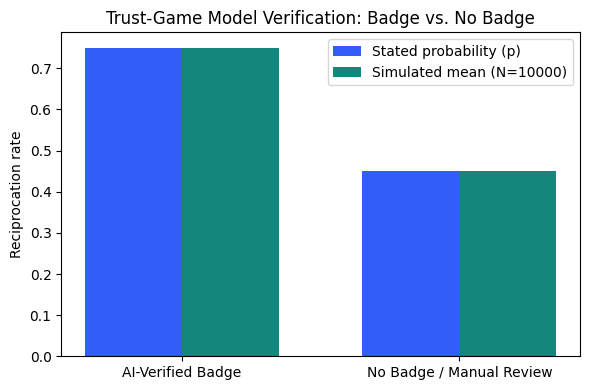

In [4]:
import matplotlib.pyplot as plt

labels = list(CONDITIONS.keys())
targets = [CONDITIONS[l] for l in labels]
simulated = [results[l] for l in labels]

x = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([i - width/2 for i in x], targets, width, label="Stated probability (p)", color="#315EFB")
ax.bar([i + width/2 for i in x], simulated, width, label=f"Simulated mean (N={N_TRIALS})", color="#14877D")
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel("Reciprocation rate")
ax.set_title("Trust-Game Model Verification: Badge vs. No Badge")
ax.legend()
plt.tight_layout()
plt.savefig("trust_game_verification.png", dpi=150)
plt.show()


## 4. Summary

- The deployed Hugging Face Space (`yt1080/Yitong-TrustGame`) encodes two illustrative
  reciprocation probabilities: **p = 0.75** (AI-Verified Badge) and **p = 0.45** (No Badge
  / Manual Review), with a single reported 10-round session of **8/10** and **3/10**
  respectively.
- This notebook independently confirms, via a 10,000-session Monte Carlo simulation, that
  both conditions converge to their stated probabilities, validating the *model* underlying
  the deployed demo.
- These are theoretical placeholders motivated by Akerlof (1970), Morozov and Feigel
  (2026), and Leung et al. (2026), **not fitted to real campus-user data**. Whether real
  students would show a comparable gap in trust or completion is anticipated, not obtained.
